<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION/blob/main/STATISTICAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face_detection', 'real_and_fake_face']


In [3]:
#Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report,precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import pandas as pd

In [4]:
#Extract Statistical Features from Images
def extract_stats_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (128,128))

    # Compute basic statistical descriptors
    mean = np.mean(img)
    std = np.std(img)
    var = np.var(img)
    skew = np.mean((img - mean)**3) / (std**3 + 1e-8)
    kurt = np.mean((img - mean)**4) / (std**4 + 1e-8)
    hist = cv2.calcHist([img], [0], None, [16], [0,256]).flatten()
    hist = hist / np.sum(hist)

    features = np.hstack([mean, std, var, skew, kurt, hist])
    return features

X, y = [], []
classes = ['real_and_fake_face/training_real', 'real_and_fake_face/training_fake']
for label, cls in enumerate(classes):
    folder = os.path.join(dataset_dir, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        feat = extract_stats_features(path)
        if feat is not None:
            X.append(feat)
            y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Extracted statistical features: {X.shape}")

Extracted statistical features: (2041, 21)


In [5]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
# Train Statistical Models
print("\nTraining statistical models...")

lr = LogisticRegression(max_iter=500)
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
lda.fit(X_train, y_train)


Training statistical models...


LinearDiscriminantAnalysis()

In [7]:
#Evaluate Models
y_pred_lr  = lr.predict(X_test)
y_pred_nb  = nb.predict(X_test)
y_pred_lda = lda.predict(X_test)

# Probabilities (for AUC)
y_prob_lr  = lr.predict_proba(X_test)[:, 1] if hasattr(lr, "predict_proba") else None
y_prob_nb  = nb.predict_proba(X_test)[:, 1] if hasattr(nb, "predict_proba") else None
y_prob_lda = lda.predict_proba(X_test)[:, 1] if hasattr(lda, "predict_proba") else None

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    return acc, prec, rec, f1, auc

lr_metrics  = compute_metrics(y_test, y_pred_lr, y_prob_lr)
nb_metrics  = compute_metrics(y_test, y_pred_nb, y_prob_nb)
lda_metrics = compute_metrics(y_test, y_pred_lda, y_prob_lda)

In [8]:
print("\nSTATISTICAL MODEL PERFORMANCE SUMMARY")
print("────────────────────────────────────────────")
print(f"Logistic Regression - Accuracy: {lr_metrics[0]*100:.2f}%, Precision: {lr_metrics[1]*100:.2f}%, Recall: {lr_metrics[2]*100:.2f}%, F1: {lr_metrics[3]*100:.2f}%, AUC: {lr_metrics[4]*100:.2f}%")
print(f"Naive Bayes          - Accuracy: {nb_metrics[0]*100:.2f}%, Precision: {nb_metrics[1]*100:.2f}%, Recall: {nb_metrics[2]*100:.2f}%, F1: {nb_metrics[3]*100:.2f}%, AUC: {nb_metrics[4]*100:.2f}%")
print(f"LDA                  - Accuracy: {lda_metrics[0]*100:.2f}%, Precision: {lda_metrics[1]*100:.2f}%, Recall: {lda_metrics[2]*100:.2f}%, F1: {lda_metrics[3]*100:.2f}%, AUC: {lda_metrics[4]*100:.2f}%")



STATISTICAL MODEL PERFORMANCE SUMMARY
────────────────────────────────────────────
Logistic Regression - Accuracy: 49.39%, Precision: 43.44%, Recall: 27.75%, F1: 33.87%, AUC: 50.42%
Naive Bayes          - Accuracy: 51.34%, Precision: 48.06%, Recall: 51.83%, F1: 49.87%, AUC: 51.76%
LDA                  - Accuracy: 50.12%, Precision: 44.80%, Recall: 29.32%, F1: 35.44%, AUC: 50.18%


In [9]:
#  Metrics DataFrame for Visualization

results_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Naive Bayes': nb_metrics,
    'LDA': lda_metrics
}, index=['accuracy','precision','recall','f1','auc']).T

display(results_df)

,accuracy,precision,recall,f1,auc
Logistic Regression,0.493888,0.434426,0.277487,0.338658,0.504203
Naive Bayes,0.513447,0.480583,0.518325,0.498741,0.517556
LDA,0.501222,0.448000,0.293194,0.354430,0.501777


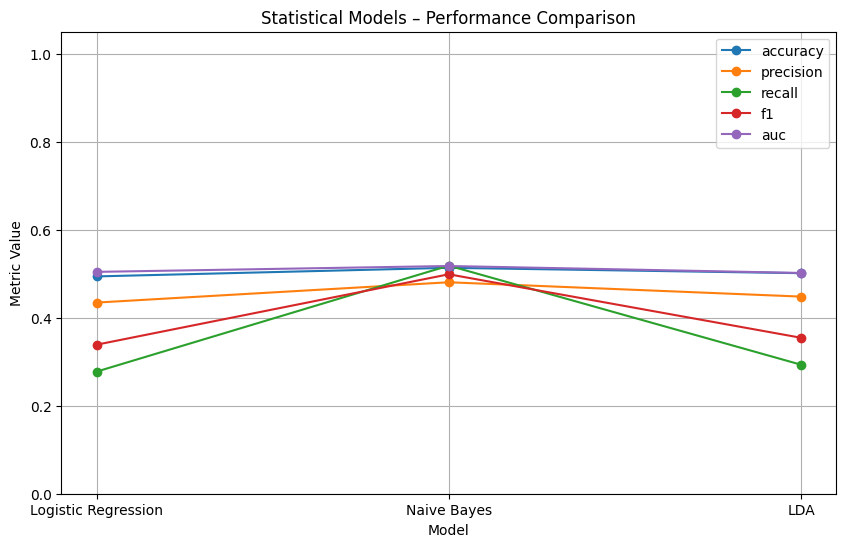

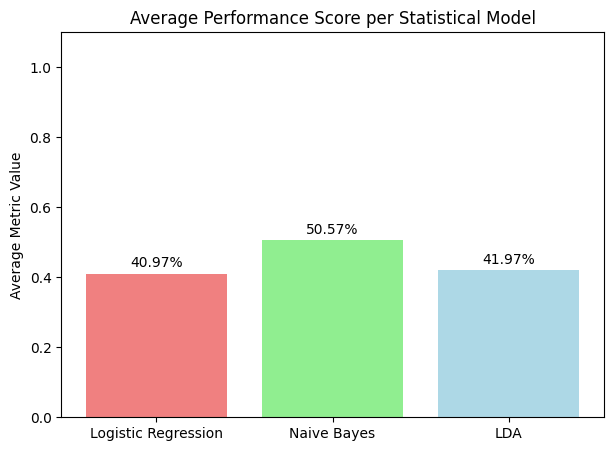

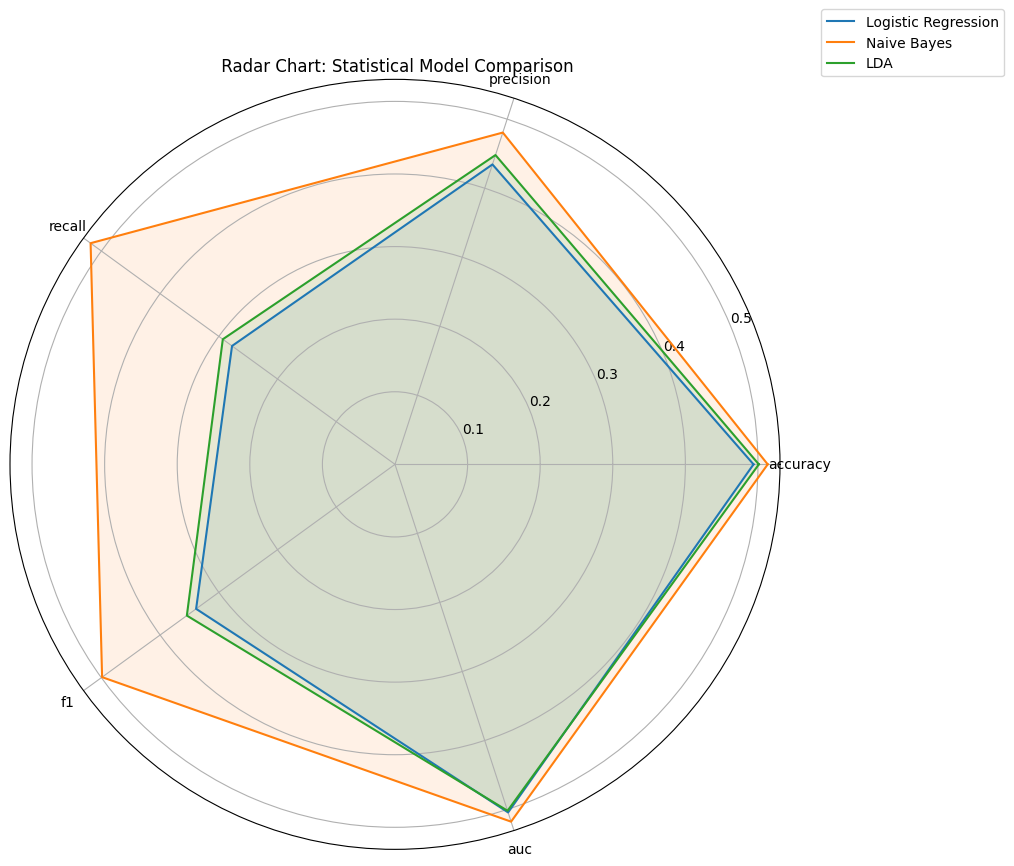

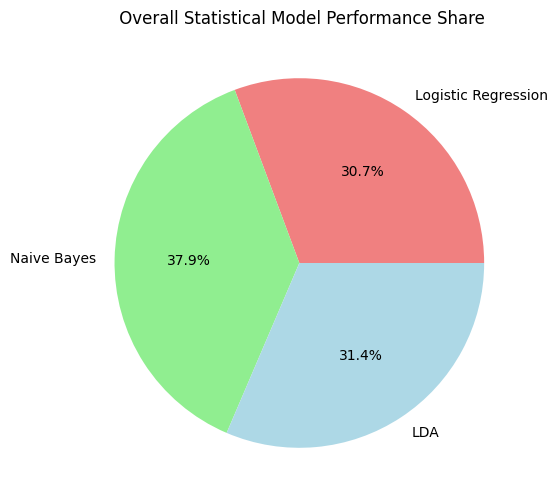

In [10]:
# Line Chart – Metric Comparison

plt.figure(figsize=(10,6))
for metric in results_df.columns:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
plt.title("Statistical Models – Performance Comparison")
plt.ylabel("Metric Value")
plt.xlabel("Model")
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()


#  Bar Chart – Average Performance

avg_scores = results_df.mean(axis=1)
plt.figure(figsize=(7,5))
bars = plt.bar(results_df.index, avg_scores, color=['lightcoral','lightgreen','lightblue'])
plt.title("Average Performance Score per Statistical Model")
plt.ylabel("Average Metric Value")

for bar, score in zip(bars, avg_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{score*100:.2f}%", ha='center', va='bottom')

plt.ylim(0,1.1)
plt.show()


# Radar Chart – Metric Profile per Model

from math import pi
metrics = list(results_df.columns)
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)
for model in results_df.index:
    values = results_df.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title(" Radar Chart: Statistical Model Comparison")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Pie Chart – Overall Performance Share

total_perf = avg_scores / avg_scores.sum()
plt.figure(figsize=(6,6))
plt.pie(total_perf, labels=avg_scores.index, autopct='%1.1f%%', colors=['lightcoral','lightgreen','lightblue'])
plt.title(" Overall Statistical Model Performance Share")
plt.show()


In [11]:
# Final Conclusion Report

best_model = avg_scores.idxmax()
print(" FINAL COMPARISON REPORT")
print("──────────────────────────────")
for model in results_df.index:
    print(f"{model}: Accuracy={results_df.loc[model,'accuracy']:.3f}, Precision={results_df.loc[model,'precision']:.3f}, Recall={results_df.loc[model,'recall']:.3f}, F1={results_df.loc[model,'f1']:.3f}, AUC={results_df.loc[model,'auc']:.3f}")
print(f"\n Best Performing Statistical Model: {best_model}")

 FINAL COMPARISON REPORT
──────────────────────────────
Logistic Regression: Accuracy=0.494, Precision=0.434, Recall=0.277, F1=0.339, AUC=0.504
Naive Bayes: Accuracy=0.513, Precision=0.481, Recall=0.518, F1=0.499, AUC=0.518
LDA: Accuracy=0.501, Precision=0.448, Recall=0.293, F1=0.354, AUC=0.502

 Best Performing Statistical Model: Naive Bayes
